# Customer Churn Prediction (Bank Customers)

Objective:
Identify customers who are likely to leave the bank.
Dataset:
Churn Modelling Dataset
Instructions:
● Clean and prepare the dataset.
● Encode categorical features such as geography and gender.
● Train a classification model.
● Analyze feature importance to understand what influences churn.

Skills:
● Categorical data encoding (Label Encoding / One-Hot Encoding)
● Supervised classification modeling
● Understanding and interpreting feature importance

In [1]:
# Importing Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report

In [2]:
data = pd.read_csv('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-3-Customer-Churn/DataSet/churn_prediction.csv')

In [3]:
data

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,30297,2325,10,Female,0.0,student,1020.0,2,1207,1076.43,...,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22
28378,30298,1537,34,Female,0.0,self_employed,1046.0,2,223,3844.10,...,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17
28379,30299,2376,47,Male,0.0,salaried,1096.0,2,588,65511.97,...,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31
28380,30300,1745,50,Male,3.0,self_employed,1219.0,3,274,1625.55,...,1683.20,1857.42,0.20,0.20,0.20,0.20,1625.55,1625.55,0,NaT


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  str    
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  str    
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  28382 non-n

In [5]:
data.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
dtype: int64

In [6]:
data.shape

(28382, 21)

In [7]:
data.gender = data.gender.fillna('Uknown')

In [8]:
data.city = data.city.fillna(data.city.mode()[0])

In [9]:
data.occupation = data.occupation.fillna(data.occupation.mode()[0])

In [10]:
data.dependents = data.dependents.fillna(data.dependents.mode()[0])

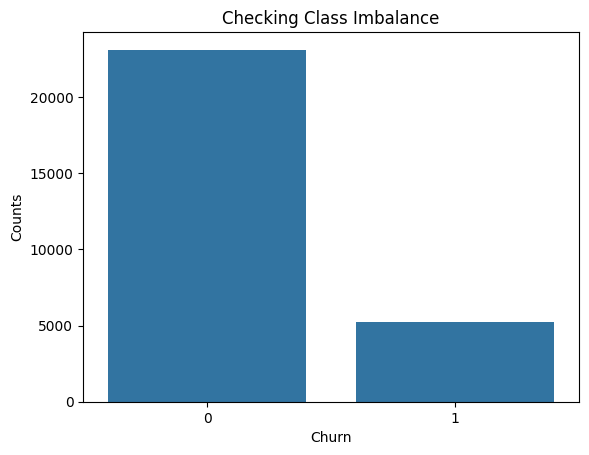

In [11]:
sns.countplot(data=data,x='churn')
plt.title('Checking Class Imbalance')
plt.xlabel('Churn')
plt.ylabel('Counts')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-3-Customer-Churn/images/Class_Imbalance.png')
plt.show()

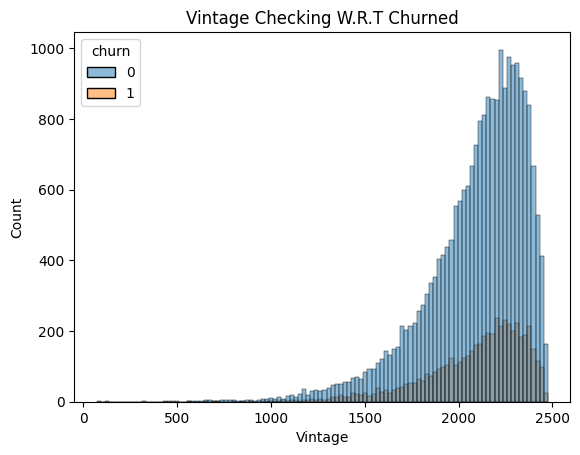

In [12]:
sns.histplot(data=data,x='vintage',hue='churn')
plt.title('Vintage Checking W.R.T Churned')
plt.xlabel('Vintage')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-3-Customer-Churn/images/Vintage Checking W.R.T Churned.png')
plt.show()

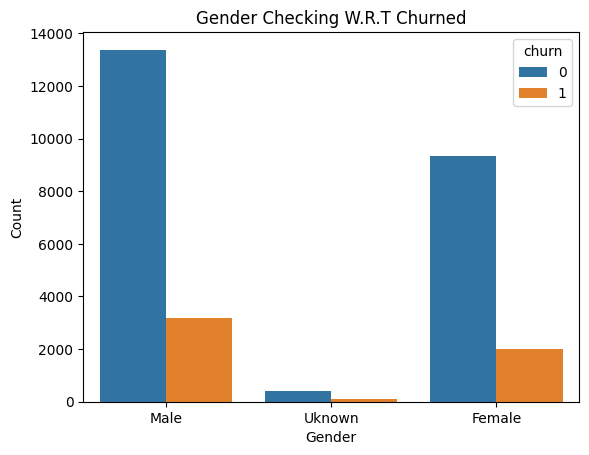

In [13]:
sns.countplot(data=data,x='gender',hue='churn')
plt.title('Gender Checking W.R.T Churned')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-3-Customer-Churn/images/Gender Checking W.R.T Churned.png')
plt.show()

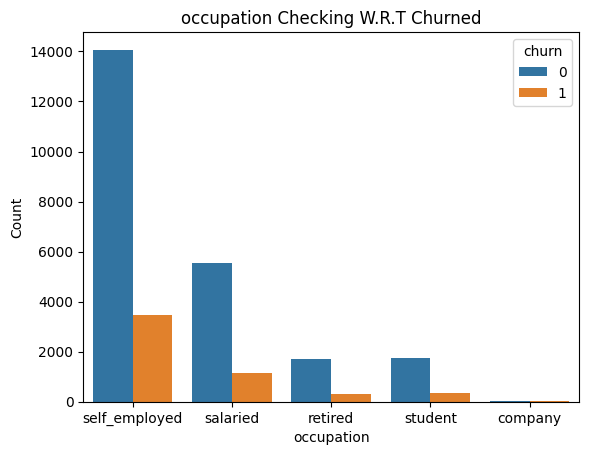

In [14]:
sns.countplot(data=data,x='occupation',hue='churn')
plt.title('occupation Checking W.R.T Churned')
plt.xlabel('occupation')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-3-Customer-Churn/images/occupation Checking W.R.T Churned.png')
plt.show()

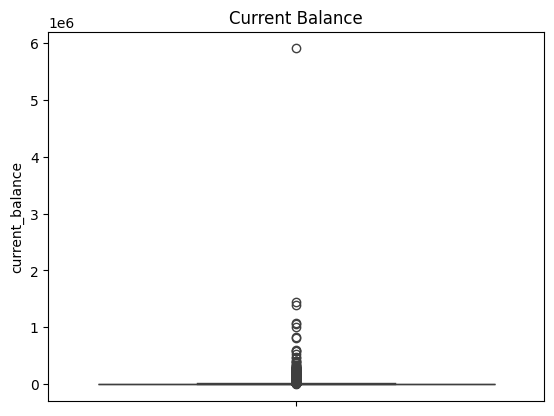

In [15]:
sns.boxplot(data=data,y='current_balance')
plt.title('Current Balance')
plt.show()

In [16]:
Q1 = data['current_balance'].quantile(0.25)
Q3 = data['current_balance'].quantile(0.75)
IQR = Q3 - Q1

data['current_balance'] = data['current_balance'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

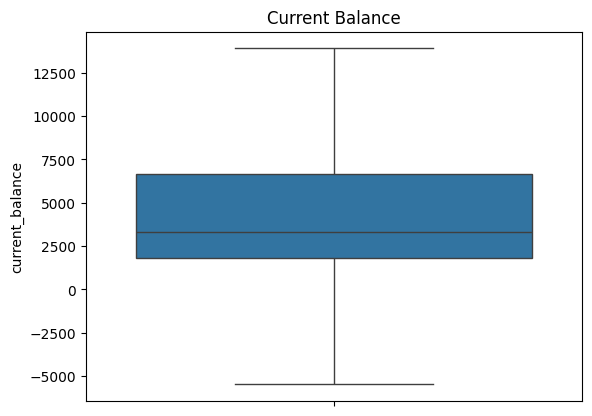

In [17]:
sns.boxplot(data=data,y='current_balance')
plt.title('Current Balance')
plt.show()

In [18]:
data.drop('customer_id',axis=1,inplace=True)

In [19]:
gender_encoder = OneHotEncoder(sparse_output=False)
data_ = gender_encoder.fit_transform(data[['gender']])
data_ = pd.DataFrame(data_,columns=gender_encoder.get_feature_names_out())
data = pd.concat([data,data_],axis=1)
data.drop('gender',axis=1,inplace=True)
data

,vintage,age,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,...,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,gender_Female,gender_Male,gender_Uknown
0,2101,66,0.0,self_employed,187.0,2,755,1458.710,1458.71,1458.71,...,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,0.0,1.0,0.0
1,2348,35,0.0,self_employed,1020.0,2,3214,5390.370,8704.66,7799.26,...,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,0.0,1.0,0.0
2,2194,31,0.0,salaried,146.0,2,41,3913.160,5815.29,4910.17,...,0.61,6046.73,259.23,5006.28,5070.14,0,NaT,0.0,1.0,0.0
3,2329,90,0.0,self_employed,1020.0,2,582,2291.910,2291.91,2084.54,...,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,0.0,0.0,1.0
4,1579,42,2.0,self_employed,1494.0,3,388,927.720,1401.72,1643.31,...,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,2325,10,0.0,student,1020.0,2,1207,1076.430,1076.43,2282.19,...,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22,1.0,0.0,0.0
28378,1537,34,0.0,self_employed,1046.0,2,223,3844.100,4069.21,3668.83,...,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17,1.0,0.0,0.0
28379,2376,47,0.0,salaried,1096.0,2,588,13912.845,61017.55,53444.81,...,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31,0.0,1.0,0.0
28380,1745,50,3.0,self_employed,1219.0,3,274,1625.550,1625.55,1683.20,...,0.20,0.20,0.20,1625.55,1625.55,0,NaT,0.0,1.0,0.0


In [20]:
data.drop('last_transaction',axis=1,inplace=True)

In [21]:
vintage_scaler = StandardScaler()
data.vintage = vintage_scaler.fit_transform(data[['vintage']])

In [22]:
age_scaler = StandardScaler()
data.age = age_scaler.fit_transform(data[['age']])

In [23]:
occupation_encoder = OneHotEncoder(sparse_output=False)
data_ = occupation_encoder.fit_transform(data[['occupation']])
data_ = pd.DataFrame(data_,columns=occupation_encoder.get_feature_names_out())
data = pd.concat([data,data_],axis=1)
data.drop('occupation',axis=1,inplace=True)
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,187.0,2,755,1458.710,1458.71,1458.71,1449.07,...,1458.71,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,1020.0,2,3214,5390.370,8704.66,7799.26,12419.41,...,8787.61,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,146.0,2,41,3913.160,5815.29,4910.17,2815.94,...,5070.14,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,1020.0,2,582,2291.910,2291.91,2084.54,1006.54,...,1669.79,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1494.0,3,388,927.720,1401.72,1643.31,1871.12,...,1677.16,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,1020.0,2,1207,1076.430,1076.43,2282.19,2787.70,...,1076.43,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,1046.0,2,223,3844.100,4069.21,3668.83,3865.55,...,3690.32,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,1096.0,2,588,13912.845,61017.55,53444.81,21925.81,...,57564.24,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,1219.0,3,274,1625.550,1625.55,1683.20,1857.42,...,1625.55,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [24]:
city_scaller = StandardScaler()
data.city = city_scaller.fit_transform(data[['city']])
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,-1.436917,2,755,1458.710,1458.71,1458.71,1449.07,...,1458.71,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,0.507942,2,3214,5390.370,8704.66,7799.26,12419.41,...,8787.61,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,-1.532642,2,41,3913.160,5815.29,4910.17,2815.94,...,5070.14,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,0.507942,2,582,2291.910,2291.91,2084.54,1006.54,...,1669.79,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1.614620,3,388,927.720,1401.72,1643.31,1871.12,...,1677.16,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,0.507942,2,1207,1076.430,1076.43,2282.19,2787.70,...,1076.43,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,0.568646,2,223,3844.100,4069.21,3668.83,3865.55,...,3690.32,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,0.685384,2,588,13912.845,61017.55,53444.81,21925.81,...,57564.24,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,0.972560,3,274,1625.550,1625.55,1683.20,1857.42,...,1625.55,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [25]:
branch_scaler = StandardScaler()
data.branch_code = branch_scaler.fit_transform(data[['branch_code']])

In [26]:
prev_month = StandardScaler()
data.previous_month_balance = prev_month.fit_transform(data[['previous_month_balance']])
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,-1.436917,2,-0.182318,1458.710,1458.71,1458.71,1449.07,...,-0.142265,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,0.507942,2,2.439824,5390.370,8704.66,7799.26,12419.41,...,0.030459,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,-1.532642,2,-0.943689,3913.160,5815.29,4910.17,2815.94,...,-0.057152,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,0.507942,2,-0.366796,2291.910,2291.91,2084.54,1006.54,...,-0.137290,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1.614620,3,-0.573667,927.720,1401.72,1643.31,1871.12,...,-0.137116,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,0.507942,2,0.299670,1076.430,1076.43,2282.19,2787.70,...,-0.151274,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,0.568646,2,-0.749614,3844.100,4069.21,3668.83,3865.55,...,-0.089671,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,0.685384,2,-0.360398,13912.845,61017.55,53444.81,21925.81,...,1.180005,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,0.972560,3,-0.695230,1625.550,1625.55,1683.20,1857.42,...,-0.138333,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
current_month = StandardScaler()
data.current_balance = current_month.fit_transform(data[['current_balance']])
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,-1.436917,2,-0.182318,-0.813062,1458.71,1458.71,1449.07,...,-0.142265,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,0.507942,2,2.439824,0.138463,8704.66,7799.26,12419.41,...,0.030459,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,-1.532642,2,-0.943689,-0.219046,5815.29,4910.17,2815.94,...,-0.057152,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,0.507942,2,-0.366796,-0.611414,2291.91,2084.54,1006.54,...,-0.137290,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1.614620,3,-0.573667,-0.941570,1401.72,1643.31,1871.12,...,-0.137116,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,0.507942,2,0.299670,-0.905580,1076.43,2282.19,2787.70,...,-0.151274,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,0.568646,2,-0.749614,-0.235759,4069.21,3668.83,3865.55,...,-0.089671,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,0.685384,2,-0.360398,2.201038,61017.55,53444.81,21925.81,...,1.180005,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,0.972560,3,-0.695230,-0.772684,1625.55,1683.20,1857.42,...,-0.138333,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [28]:
prev_month = StandardScaler()
data.previous_month_end_balance = prev_month.fit_transform(data[['previous_month_end_balance']])

In [29]:
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,-1.436917,2,-0.182318,-0.813062,-0.141953,1458.71,1449.07,...,-0.142265,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,0.507942,2,2.439824,0.138463,0.028425,7799.26,12419.41,...,0.030459,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,-1.532642,2,-0.943689,-0.219046,-0.039514,4910.17,2815.94,...,-0.057152,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,0.507942,2,-0.366796,-0.611414,-0.122361,2084.54,1006.54,...,-0.137290,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1.614620,3,-0.573667,-0.941570,-0.143293,1643.31,1871.12,...,-0.137116,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,0.507942,2,0.299670,-0.905580,-0.150942,2282.19,2787.70,...,-0.151274,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,0.568646,2,-0.749614,-0.235759,-0.080571,3668.83,3865.55,...,-0.089671,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,0.685384,2,-0.360398,2.201038,1.258489,53444.81,21925.81,...,1.180005,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,0.972560,3,-0.695230,-0.772684,-0.138030,1683.20,1857.42,...,-0.138333,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
avg_monthly = StandardScaler()
data.average_monthly_balance_prevQ = avg_monthly.fit_transform(data[['average_monthly_balance_prevQ']])
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,-1.436917,2,-0.182318,-0.813062,-0.141953,-0.144709,1449.07,...,-0.142265,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,0.507942,2,2.439824,0.138463,0.028425,0.007249,12419.41,...,0.030459,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,-1.532642,2,-0.943689,-0.219046,-0.039514,-0.061991,2815.94,...,-0.057152,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,0.507942,2,-0.366796,-0.611414,-0.122361,-0.129711,1006.54,...,-0.137290,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1.614620,3,-0.573667,-0.941570,-0.143293,-0.140285,1871.12,...,-0.137116,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,0.507942,2,0.299670,-0.905580,-0.150942,-0.124974,2787.70,...,-0.151274,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,0.568646,2,-0.749614,-0.235759,-0.080571,-0.091741,3865.55,...,-0.089671,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,0.685384,2,-0.360398,2.201038,1.258489,1.101198,21925.81,...,1.180005,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,0.972560,3,-0.695230,-0.772684,-0.138030,-0.139329,1857.42,...,-0.138333,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [31]:
avg_monthlyq2 = StandardScaler()
data.average_monthly_balance_prevQ2 = avg_monthlyq2.fit_transform(data[['average_monthly_balance_prevQ2']])
data

,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,...,previous_month_balance,churn,gender_Female,gender_Male,gender_Uknown,occupation_company,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,0.036146,0.999147,0.0,-1.436917,2,-0.182318,-0.813062,-0.141953,-0.144709,-0.127317,...,-0.142265,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.941996,-0.741756,0.0,0.507942,2,2.439824,0.138463,0.028425,0.007249,0.118793,...,0.030459,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.377215,-0.966389,0.0,-1.532642,2,-0.943689,-0.219046,-0.039514,-0.061991,-0.096652,...,-0.057152,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.872315,2.346943,0.0,0.507942,2,-0.366796,-0.611414,-0.122361,-0.129711,-0.137244,...,-0.137290,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.878243,-0.348649,2.0,1.614620,3,-0.573667,-0.941570,-0.143293,-0.140285,-0.117848,...,-0.137116,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28377,0.857646,-2.145710,0.0,0.507942,2,0.299670,-0.905580,-0.150942,-0.124974,-0.097286,...,-0.151274,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28378,-2.032274,-0.797914,0.0,0.568646,2,-0.749614,-0.235759,-0.080571,-0.091741,-0.073105,...,-0.089671,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28379,1.044683,-0.067858,0.0,0.685384,2,-0.360398,2.201038,1.258489,1.101198,0.332060,...,1.180005,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28380,-1.269452,0.100617,3.0,0.972560,3,-0.695230,-0.772684,-0.138030,-0.139329,-0.118156,...,-0.138333,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   vintage                         28382 non-null  float64
 1   age                             28382 non-null  float64
 2   dependents                      28382 non-null  float64
 3   city                            28382 non-null  float64
 4   customer_nw_category            28382 non-null  int64  
 5   branch_code                     28382 non-null  float64
 6   current_balance                 28382 non-null  float64
 7   previous_month_end_balance      28382 non-null  float64
 8   average_monthly_balance_prevQ   28382 non-null  float64
 9   average_monthly_balance_prevQ2  28382 non-null  float64
 10  current_month_credit            28382 non-null  float64
 11  previous_month_credit           28382 non-null  float64
 12  current_month_debit             28382 non-n

In [33]:
# Model Trainning 

In [34]:
X = data.drop('churn',axis=1)
y = data['churn']

In [35]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   # 20% test, 80% train
    random_state=42, # for reproducibility
    stratify=y       # preserve class distribution
)

In [36]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train,y_train)
prediction = logistic_regression.predict(X_test)
print(f'''
      Logistic Regression :
Accuracy Score = {accuracy_score(y_test,prediction)}
Precision Score = {precision_score(y_test,prediction)}
Recall Score = {recall_score(y_test,prediction)}
Confusion Matrix {confusion_matrix(y_test,prediction)}
Classification report {classification_report(y_test,prediction)}
''')


      Logistic Regression :
Accuracy Score = 0.815747754095473
Precision Score = 0.56
Recall Score = 0.026615969581749048
Confusion Matrix [[4603   22]
 [1024   28]]
Classification report               precision    recall  f1-score   support

           0       0.82      1.00      0.90      4625
           1       0.56      0.03      0.05      1052

    accuracy                           0.82      5677
   macro avg       0.69      0.51      0.47      5677
weighted avg       0.77      0.82      0.74      5677




/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train,y_train)
prediction = decision_tree.predict(X_test)

print(f'''
      Decision Tree :
Accuracy Score = {accuracy_score(y_test,prediction)}
Precision Score = {precision_score(y_test,prediction)}
Recall Score = {recall_score(y_test,prediction)}
Confusion Matrix {confusion_matrix(y_test,prediction)}
Classification report {classification_report(y_test,prediction)}
''')


      Decision Tree :
Accuracy Score = 0.7858023604016205
Precision Score = 0.42531876138433516
Recall Score = 0.4439163498098859
Confusion Matrix [[3994  631]
 [ 585  467]]
Classification report               precision    recall  f1-score   support

           0       0.87      0.86      0.87      4625
           1       0.43      0.44      0.43      1052

    accuracy                           0.79      5677
   macro avg       0.65      0.65      0.65      5677
weighted avg       0.79      0.79      0.79      5677




In [46]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train,y_train)
prediction = random_forest.predict(X_test)

print(f'''
      Random Forest :
Accuracy Score = {accuracy_score(y_test,prediction)}
Precision Score = {precision_score(y_test,prediction)}
Recall Score = {recall_score(y_test,prediction)}
Confusion Matrix {confusion_matrix(y_test,prediction)}
Classification report {classification_report(y_test,prediction)}
''')


      Random Forest :
Accuracy Score = 0.8620750396336093
Precision Score = 0.7252931323283082
Recall Score = 0.41159695817490494
Confusion Matrix [[4461  164]
 [ 619  433]]
Classification report               precision    recall  f1-score   support

           0       0.88      0.96      0.92      4625
           1       0.73      0.41      0.53      1052

    accuracy                           0.86      5677
   macro avg       0.80      0.69      0.72      5677
weighted avg       0.85      0.86      0.85      5677




In [44]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)
predict = knn.predict(X_test)

print(f'''
      Knn :
Accuracy Score = {accuracy_score(y_test,predict)}
Precision Score = {precision_score(y_test,predict)}
Recall Score = {recall_score(y_test,predict)}
Confusion Matrix {confusion_matrix(y_test,predict)}
Classification report {classification_report(y_test,predict)}
''')


      Knn :
Accuracy Score = 0.8263167165756562
Precision Score = 0.5812807881773399
Recall Score = 0.22433460076045628
Confusion Matrix [[4455  170]
 [ 816  236]]
Classification report               precision    recall  f1-score   support

           0       0.85      0.96      0.90      4625
           1       0.58      0.22      0.32      1052

    accuracy                           0.83      5677
   macro avg       0.71      0.59      0.61      5677
weighted avg       0.80      0.83      0.79      5677


